---
### 07. Class
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

Mounted at /content/drive


#### 1. Class 정의 및 사용

In [2]:
class Dog:
  def __init__(self, name, age):
    self.name = name
    self.age = age
  def bark(self):
    return f"{self.name} is barking now."
  def get_age(self):
    return f"{self.name} is {self.age} years old."

In [3]:
dog1 = Dog(name = '진돗개', age=3)
dog2 = Dog(name = '시추', age=5)
dog3 = Dog(name = '푸들', age=2)

print(dog1.bark(), dog2.bark(), dog3.bark())
print(dog1.get_age(), dog2.get_age(), dog3.get_age())

진돗개 is barking now. 시추 is barking now. 푸들 is barking now.
진돗개 is 3 years old. 시추 is 5 years old. 푸들 is 2 years old.


#### 2. 함수 모델 vs. 클래스 선언

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [5]:
# 함수방식
n_feature = 10
model = nn.Sequential(
    nn.Linear(n_feature, 3),
    nn.ReLU(),
    nn.Linear(3,1)
).to(device)

In [6]:
# 클래스선언 방식
class NeuralNet(nn.Module):
  def __int__(self, n_feature):
    super().__int__()                   # 현재 객체를 부모클래스(nn.Module) 기준으로 초기화
    self.fc1 = nn.Linear(n_feature, 3)  # fc: full conneted
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(3,1)
  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x

#### 3. 클래스 선언방식
- 직접선언 vs. 기본 / 중첩 / 모듈화

In [7]:
# 직접선언
n_feature = 28*28
n_class = 10

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_feature, 256),
    nn.ReLU(),
    nn.Dropout(p=.3),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(p=.3),
    nn.Linear(64, n_class)
).to(device)

In [8]:
# 1. 기본 클래스
class NeuralNet1(nn.Module):
  def __init__(self, n_feature, n_class):
    super().__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(n_feature, 256)
    self.fc2 = nn.Linear(256, 64)
    self.fc3 = nn.Linear(64, n_class)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(p=.3)

  def forward(self, x):
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc3(x)
    return(x)

model = NeuralNet1(n_feature=28*28, n_class=10).to(device)

In [9]:
# 2. 중첩
class NeuralNet2(nn.Module):
  def __init__(self, n_feature, n_class):
    super().__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(n_feature, 256)
    self.fc2 = nn.Linear(256, 64)
    self.fc3 = nn.Linear(64, n_class)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(p=.3)

  def forward(self, x):
    x = self.flatten(x)
    x = self.dropout(self.relu(self.fc1(x)))
    x = self.dropout(self.relu(self.fc2(x)))
    x = self.fc3(x)
    return(x)

model = NeuralNet2(n_feature=28*28, n_class=10).to(device)

In [10]:
# 3. 모듈화
class NeuralNet3(nn.Module):
  def __init__(self, n_feature, n_class):
    super().__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Sequential(
        nn.Linear(n_feature, 256),
        nn.ReLU(),
        nn.Dropout(p=.3)
    )
    self.fc2 = nn.Sequential(
        nn.Linear(256, 64), nn.ReLU(), nn.Dropout(p=.3)
    )
    self.fc3 = nn.Linear(64, n_class)

  def forward(x):
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.fc2(x)
    x = self.fc3(x)
    return(x)

model = NeuralNet3(n_feature=28*28, n_class = 10).to(device)

#### 4. Class modeling 실습

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# data loader
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor

# training function
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0

    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정

        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.

    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()

# eval function
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정

    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산

    return eval_loss, pred

# learning curve
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [12]:
# MNIST 데이터 다운로드
from torchvision import datasets
from torchvision.transforms import ToTensor
train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=ToTensor())
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor())

# 학습 데이터로 데이터 로더 구성
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size)

# 검증/테스트 데이터 준비 (분할,스케일링,차원맞추기)
x_val, x_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

x_val = x_val / 255
x_test = x_test/ 255

x_val = x_val.view(5000, 1, 28, 28)
x_test = x_test.view(5000, 1, 28, 28)

In [13]:
# modeling by class
class NeuralNet4(nn.Module):
  def __init__(self, n_feature, n_class):
    super().__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(n_feature, 256)
    self.fc2 = nn.Linear(256, 64)
    self.fc3 = nn.Linear(64, n_class)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(p=.3)

  def forward(self, x):
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc3(x)
    return x

Epoch 1. train loss: 0.4080, val loss: 0.2221
Epoch 2. train loss: 0.1893, val loss: 0.1554
Epoch 3. train loss: 0.1412, val loss: 0.1260
Epoch 4. train loss: 0.1158, val loss: 0.1195
Epoch 5. train loss: 0.0961, val loss: 0.1089
Epoch 6. train loss: 0.0897, val loss: 0.1010
Epoch 7. train loss: 0.0778, val loss: 0.1082
Epoch 8. train loss: 0.0710, val loss: 0.1098
Epoch 9. train loss: 0.0670, val loss: 0.0970
Epoch 10. train loss: 0.0609, val loss: 0.1055


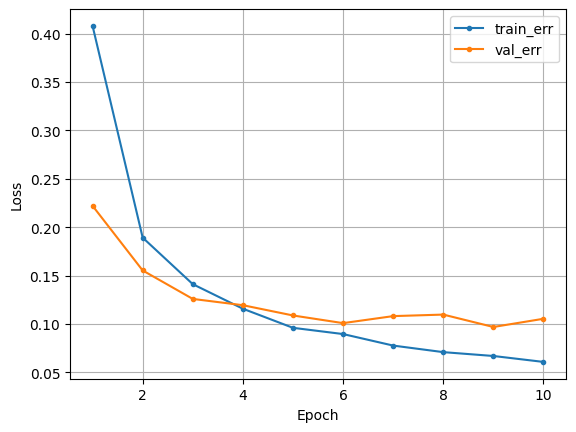

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       520
           1       1.00      0.99      0.99       564
           2       0.99      0.98      0.99       502
           3       0.98      0.99      0.98       510
           4       1.00      0.98      0.99       482
           5       0.98      0.99      0.98       436
           6       0.99      0.99      0.99       496
           7       0.98      0.99      0.99       516
           8       0.98      0.99      0.99       485
           9       0.99      0.98      0.98       489

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



In [14]:
# define model
model = NeuralNet4(n_feature=28*28, n_class=10).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

# training
epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
  tr_loss = train(train_loader, model, loss_fn, optimizer, device)
  val_loss, _ = evaluate(x_val, y_val, model, loss_fn, device)
  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"Epoch {t+1}. train loss: {tr_loss:.4f}, val loss: {val_loss:.4f}")

# learning curve
dl_learning_curve(tr_loss_list, val_loss_list)

# preidct, eval
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis=1)
print(classification_report(y_test, pred))

#### 5. 다층 입력 구조

In [33]:
# data loading and target split
data = pd.read_csv('data/boston_housing_price.csv')
display(data.head())

y = data['medv']
X = data.drop('medv', axis=1)

# 직접요인: X1, 간접요인: X2
x1_cols = ['rm', 'age', 'zn', 'tax', 'indus']
x2_cols = ['crim', 'lstat', 'nox', 'dis', 'ptratio', 'rad']
x1 = data.loc[:, x1_cols]
x2 = data.loc[:, x2_cols]

# sacling
from sklearn.preprocessing import StandardScaler
scaler1 = StandardScaler()
scaler2 = StandardScaler()

x1 = scaler1.fit_transform(x1)
x2 = scaler2.fit_transform(x2)
y = y.values # target을 numpy로 변환

# train/test 분할
x1_train, x1_test, x2_train, x2_test, y_train, y_test = train_test_split(x1, x2, y, test_size=0.2)
print(x1_train.shape, x1_test.shape, x2_train.shape, x2_test.shape, y_train.shape, y_test.shape)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


(404, 5) (102, 5) (404, 6) (102, 6) (404,) (102,)


In [34]:
# data loader
def make_DataSet(x1_train, x1_test, x2_train, x2_test, y_train, y_test, batch_size=32):
  #tensor변환
  x1_train = torch.tensor(x1_train, dtype=torch.float32)
  x2_train = torch.tensor(x2_train, dtype=torch.float32)
  y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
  x1_test = torch.tensor(x1_test, dtype=torch.float32)
  x2_test = torch.tensor(x2_test, dtype=torch.float32)
  y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
  #tensor dataset
  train_dataset = TensorDataset(x1_train, x2_train, y_train)
  #data loader
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  return train_loader, x1_test, x2_test, y_test

In [35]:
train_loader, x1_test, x2_test, y_test = make_DataSet(x1_train, x1_test, x2_train, x2_test, y_train, y_test, batch_size=32)

In [36]:
# model class
class MultiInputNet(nn.Module):
    def __init__(self, input1_dim, input2_dim):
        super(MultiInputNet, self).__init__()
        self.fc1_branch = nn.Sequential(nn.Linear(input1_dim, 16), nn.ReLU())
        self.fc2_branch = nn.Sequential(nn.Linear(input2_dim, 16), nn.ReLU())
        self.fc_combined = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1))
    def forward(self, x1, x2):
        out1 = self.fc1_branch(x1)
        out2 = self.fc2_branch(x2)
        combined = torch.cat((out1, out2), dim=1)
        output = self.fc_combined(combined)
        return output

In [37]:
# training function
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0
    model.train()
    for batch, (x1, x2, y) in enumerate(dataloader):
        x1, x2, y = x1.to(device), x2.to(device), y.to(device)
        pred = model(x1, x2)
        loss = loss_fn(pred, y)
        tr_loss += loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    tr_loss /= num_batches
    return tr_loss.item()

# eval function
def evaluate(x1, x2, y, model, loss_fn, device):
    model.eval()
    with torch.no_grad():
        x1, x2, y = x1.to(device), x2.to(device), y.to(device)
        pred = model(x1, x2)
        eval_loss = loss_fn(pred, y).item()
    return eval_loss, pred

In [38]:
# run
# 모델 선언
input1_dim, input2_dim = len(x1_cols), len(x2_cols)
model = MultiInputNet(input1_dim, input2_dim).to(device)

# 오차 함수, 옵티마이저 지정
loss_fn = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.01)

# 학습
epochs = 50
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x1_test, x2_test, y_test, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 550.843506, val loss : 484.628998
Epoch 2, train loss : 341.296112, val loss : 165.833115
Epoch 3, train loss : 85.233536, val loss : 71.208366
Epoch 4, train loss : 49.792351, val loss : 21.465292
Epoch 5, train loss : 33.736237, val loss : 15.452305
Epoch 6, train loss : 27.527372, val loss : 13.179282
Epoch 7, train loss : 24.711765, val loss : 11.308865
Epoch 8, train loss : 22.540014, val loss : 10.539654
Epoch 9, train loss : 21.121469, val loss : 10.017365
Epoch 10, train loss : 19.350594, val loss : 9.368218
Epoch 11, train loss : 17.489828, val loss : 8.992614
Epoch 12, train loss : 17.347517, val loss : 8.567729
Epoch 13, train loss : 16.777584, val loss : 8.816466
Epoch 14, train loss : 15.815911, val loss : 8.538126
Epoch 15, train loss : 14.871752, val loss : 8.308278
Epoch 16, train loss : 14.371476, val loss : 8.311909
Epoch 17, train loss : 13.963393, val loss : 8.163017
Epoch 18, train loss : 13.601707, val loss : 8.228172
Epoch 19, train loss : 1

In [40]:
from sklearn.metrics import *
_, pred = evaluate(x1_test, x2_test, y_test, model, loss_fn, device)
mae = mean_absolute_error(y_test.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_test.cpu().numpy(), pred.cpu().numpy())
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MAE : 2.2642369270324707
MAPE : 0.11008840799331665


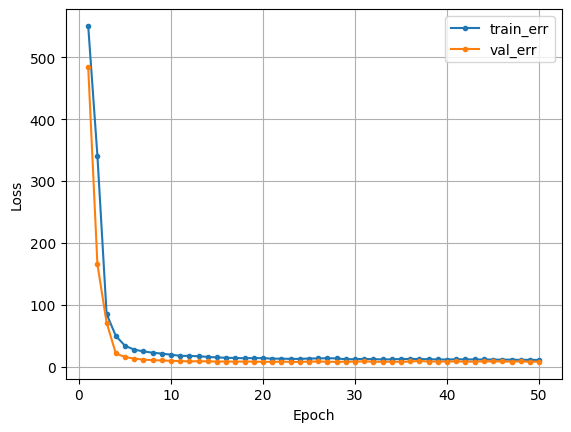

In [41]:
# learning curve
dl_learning_curve(tr_loss_list, val_loss_list)